### Import

In [1]:
from sklearn.metrics import  f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import warnings

import mlflow
import os




### Constant

In [2]:
DATAPATH = "../../data/data.pkl"
EXP_NAME = "fraud_detection"
MODEL_NAME = "fraud_detector"
MLFLOW_URI = "http://127.0.0.1:5000/"
MLFLOW_DB = "sqlite:///../../data/mlflow/fraud_detection.db"
ARTIFACT_PATH = f"file://{os.path.abspath('../../data/mlflow/artifacts')}"
RANDOM_STATE = 42

### Read Data

In [3]:
df = pd.read_pickle(DATAPATH)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1777056,162,CASH_OUT,183806.32,C691771226,19391.00,0.00,C1416312719,382572.19,566378.51,0,0
1350600,137,PAYMENT,521.37,C203378011,0.00,0.00,M42773300,0.00,0.00,0,0
1991933,179,PAYMENT,3478.18,C1698571270,19853.00,16374.82,M643984524,0.00,0.00,0,0
5092368,355,PAYMENT,1716.05,C913764937,5769.17,4053.13,M1387429131,0.00,0.00,0,0
5066515,354,CASH_IN,253129.93,C2017736577,1328499.49,1581629.42,C407484102,2713220.48,2460090.55,0,0


### EDA

In [4]:
# What are the different type of transactions ?
df.type.value_counts()

type
CASH_OUT    10840
PAYMENT      6443
TRANSFER     5655
CASH_IN      4227
DEBIT         111
Name: count, dtype: int64

In [5]:
# Target porportion
df.isFraud.value_counts(normalize=True)

isFraud
0    0.698893
1    0.301107
Name: proportion, dtype: float64

In [6]:
# Fraud per type of transactions
df[df.isFraud == 1].type.value_counts(normalize=True)

type
CASH_OUT    0.501157
TRANSFER    0.498843
Name: proportion, dtype: float64

#### Preprocess

In [7]:
def wrangle(df):
    df = df.copy()

    cols = []

    # Features leakage
    cols.append("newbalanceDest")
    cols.append("newbalanceOrig")

    # transform step into time
    df["time"] = df["step"].apply(lambda step: (step - 1) % 24 + 1)
    cols.append("step")

    # System Flag
    cols.append("isFlaggedFraud")

    # keep only type of customers M or C
    df["nameOrig"] = df["nameOrig"].str[0]
    df["nameDest"] = df["nameDest"].str[0]
    

    df.drop(columns=cols, inplace=True)
    return df


In [8]:
df_preprocessed = wrangle(df)

### Model

In [9]:
target = "isFraud"
X = df.drop(columns=[target])
y = df[target]

In [10]:
cat_cols = df.select_dtypes("object").columns.tolist()

/var/folders/q0/tlxqcyzj4bl5486b7j7s6ymw0000gn/T/ipykernel_4709/2502784212.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes("object").columns.tolist()


In [11]:
# Split data
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

#### Setup Tracking server

In [12]:
mlflow.set_tracking_uri(MLFLOW_DB)
mlflow.create_experiment(EXP_NAME, artifact_location=ARTIFACT_PATH)
mlflow.set_experiment(EXP_NAME)

2026/05/26 00:34:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/26 00:34:44 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///Users/serge-nd/IdeaProjects/DSA/data/mlflow/artifacts', creation_time=1779748484803, experiment_id='1', last_update_time=1779748484803, lifecycle_stage='active', name='fraud_detection', tags={}, workspace='default'>

In [34]:
def tracking_expirement(run_name, model_name, pipe, X_test, X_train):
    with mlflow.start_run(run_name=run_name):
        
        target_names = ["is_not_fraud", "is_fraud"]

        # ***************Log dataset**************************
        
        test_dataset = mlflow.data.from_pandas(X_test)
        mlflow.log_input(dataset=test_dataset, context="test")

        train_dataset = mlflow.data.from_pandas(X_train)
        mlflow.log_input(dataset=train_dataset, context="train")

        print("Dataset Logged !")
        # *************** Log metrics **************************
        
        pipe.fit(X_train, y_train)


        accurary = pipe.score(X_train, y_train)
        f1_metric = f1_score(y_train, pipe.predict(X_train))

        accurary_test = pipe.score(X_test, y_test)
        f1_metric_test = f1_score(y_test, pipe.predict(X_test))

        mlflow.log_metrics({
            "accuracy_train": round(accurary, 2),
            "f1_score_train": round(f1_metric,2) ,
            "accuracy_test": round(accurary_test,2),
            "f1_score_test": round(f1_metric_test,2)
        })

        print("Training score", accurary)
        print("F1 score training", f1_metric)

        print("Test score", accurary_test)
        print("F1 score test", f1_metric_test)

        print(classification_report(y_true=y_test, y_pred=pipe.predict(X_test), target_names=target_names))
       
        print("Metrics logged !")
        # *************** Log model **************************

        mlflow.sklearn.log_model(pipe, name=model_name)
        print("Model Logged !")

        cm = confusion_matrix(y_true=y_test, y_pred=pipe.predict(X_test))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=target_names)
        disp.plot()

        # *************** Log figure **************************

        mlflow.log_figure(disp.figure_, f"confusion_matrix_{model_name}.png")
        print("Confusion matrix logged !")

#### Baseline

In [14]:
# Target porportion
df.isFraud.value_counts(normalize=True)

isFraud
0    0.698893
1    0.301107
Name: proportion, dtype: float64

#### Random Forest

##### Build

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"  # keeps numeric columns as-is
)

rf_pipe = make_pipeline(
    preprocessor,
    RandomForestClassifier()
)

##### Iterate

/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing val

Dataset Logged !
Training score 1.0
F1 score training 1.0
Test score 0.9763563049853372
F1 score test 0.9598005609224057


2026/05/26 01:01:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

is_not_fraud       0.98      0.99      0.98      3827
    is_fraud       0.97      0.95      0.96      1629

    accuracy                           0.98      5456
   macro avg       0.98      0.97      0.97      5456
weighted avg       0.98      0.98      0.98      5456

Metrics logged !
Model Logged !
Confusion matrix logged !


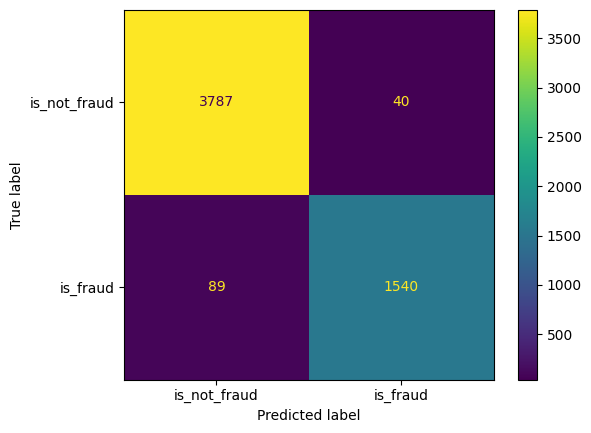

In [35]:
run_name = "random_forest"

tracking_expirement(run_name, MODEL_NAME, rf_pipe, X_train=X_train, X_test=X_test)

#### Xgboost

##### Build

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"  # keeps numeric columns as-is
)

xg_pipe = make_pipeline(
    preprocessor,
    XGBClassifier()
)

#### Iterate

/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/Users/serge-nd/IdeaProjects/DSA/.training/lib/python3.11/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing val

Dataset Logged !


2026/05/26 01:01:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training score 0.9994958753437213
F1 score training 0.9991645781119465
Test score 0.9948680351906158
F1 score test 0.9914477703115455
              precision    recall  f1-score   support

is_not_fraud       1.00      0.99      1.00      3827
    is_fraud       0.99      1.00      0.99      1629

    accuracy                           0.99      5456
   macro avg       0.99      1.00      0.99      5456
weighted avg       0.99      0.99      0.99      5456

Metrics logged !
Model Logged !
Confusion matrix logged !


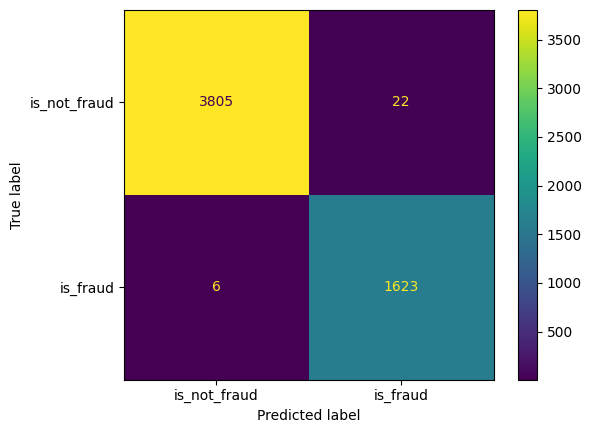

In [37]:
run_name = "xgboost"

tracking_expirement(run_name, MODEL_NAME, xg_pipe, X_train=X_train, X_test=X_test)

### Register the best model

In [ ]:
def register_best_model(experiment_name, model_name):
    
    # Get experiment by name
    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found")

    # Search all runs in the experiment, ordered by f1_score_test descending
    best_run = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=["metrics.f1_score_test DESC"],
        max_results=1
    )

    if best_run.empty:
        raise ValueError(f"No runs found in experiment '{experiment_name}'")

    best_run_id = best_run.iloc[0]["run_id"]
    best_run_name = best_run.iloc[0]["tags.mlflow.runName"]
    best_f1    = best_run.iloc[0]["metrics.f1_score_test"]

    print(f"Best run ID : {best_run_id}")
    print(f"Best F1 test: {best_f1:.4f}")

    # Register the model from the best run
    model_uri = f"runs:/{best_run_id}/{model_name}"
    registered = mlflow.register_model(model_uri=model_uri, name=model_name)

    client = mlflow.tracking.MlflowClient()
    client.set_model_version_tag(
        name=model_name,
        version=registered.version,
        key="run_name",
        value=best_run_name
    )

    print(f"Model '{model_name}' registered — version {registered.version}")
    print(f"Tagged with run_name: {best_run_name}")
    return registered


    print(f"Model '{model_name}' registered — version {registered.version}")
    return registered

In [30]:
register_best_model(
    experiment_name=EXP_NAME,
    model_name=MODEL_NAME
)

Registered model 'fraud_detector' already exists. Creating a new version of this model...
2026/05/26 00:45:57 WARNING mlflow.tracking._model_registry.fluent: Run with id 2f7adef3c5684eacb94eb91f43ae46bb has no artifacts at artifact path 'fraud_detector', registering model based on models:/m-baaa8cda2c3a4e1ba4a73efe1b73b5f7 instead


Best run ID : 2f7adef3c5684eacb94eb91f43ae46bb
Best F1 test: 0.9900
Model 'fraud_detector' registered — version 2
Tagged with run_name: xgboost


Created version '2' of model 'fraud_detector'.


<ModelVersion: aliases=[], creation_timestamp=1779749157771, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1779749157771, metrics=None, model_id=None, name='fraud_detector', params=None, run_id='2f7adef3c5684eacb94eb91f43ae46bb', run_link=None, source='models:/m-baaa8cda2c3a4e1ba4a73efe1b73b5f7', status='READY', status_message=None, tags={}, user_id=None, version=2, workspace='default'>